# Chemical Space Exploration of EU Pesticides

This notebook explores ~495 EU pesticide structures using **molecular descriptors** and **unsupervised machine learning**.

**Workflow**
1. Load SMILES strings and convert them to RDKit molecule objects
2. Compute a feature matrix (Mordred descriptors by default; RDKit fingerprint options shown)
3. Colour every scatter plot by a physicochemical property (TPSA by default)
4. Reduce dimensions with **PCA → UMAP → t-SNE**
5. Cluster with **K-Means** — once on the t-SNE embedding, once in full feature space

---
### Key terms
| Term | Meaning |
|---|---|
| **SMILES** | Text encoding of a molecule, e.g. `CCO` = ethanol |
| **Fingerprint** | Binary vector (0/1) of structural features |
| **Descriptor** | Continuous number describing a molecular property |
| **Chemical space** | Imaginary space where similar molecules sit close together |
| **Clustering** | Automatic grouping without labelled examples (unsupervised) |

## 1 — Imports

Install all required packages once:
```bash
uv add rdkit scikit-learn umap-learn mordredcommunity
```

In [16]:
import warnings
warnings.filterwarnings('ignore')  # suppress RDKit / sklearn verbosity

# data
import pandas as pd   # https://pandas.pydata.org/docs/
import numpy as np    # https://numpy.org/doc/stable/

# plotting
import matplotlib.pyplot as plt   # https://matplotlib.org/stable/
import seaborn as sns             # https://seaborn.pydata.org/
sns.set_theme(style='whitegrid', palette='tab10')

# cheminformatics
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdFingerprintGenerator
# https://www.rdkit.org/docs/GettingStartedInPython.html

# machine learning
from sklearn.decomposition import PCA       # https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
from sklearn.manifold import TSNE           # https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
from sklearn.cluster import KMeans         # https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
from sklearn.preprocessing import StandardScaler

# dimensionality reduction
import umap  # https://umap-learn.readthedocs.io/en/latest/

print('All imports successful!')

All imports successful!


## 2 — Load data and parse molecules

In [17]:
df_raw = pd.read_csv('pesticides_smiles.csv')
print(f'Raw table: {df_raw.shape[0]} rows')

# Drop rows without a SMILES (biological agents, plant viruses, etc.)
df = df_raw.dropna(subset=['smiles']).reset_index(drop=True)
print(f'After dropping missing SMILES: {len(df)} molecules')
df.head(3)

Raw table: 679 rows
After dropping missing SMILES: 495 molecules


,name,xml_name,cas,smiles
0,"1,1-dichloro-2,2-bis(4-ethylphenyl)ethane","1,1-dichloro-2,2-bis(4-ethylphenyl)ethane (F)",NaN,CCC1=CC=C(C=C1)C(C2=CC=C(C=C2)CC)C(Cl)Cl
1,"1,2-Dibromoethane","1,2-dibromoethane (ethylene dibromide) (F)",106-93-4,C(CBr)Br
2,"1,2-Dichloroethane","1,2-dichloroethane (ethylene dichloride) (F)",107-06-2,C(CCl)Cl


Valid molecules: 495


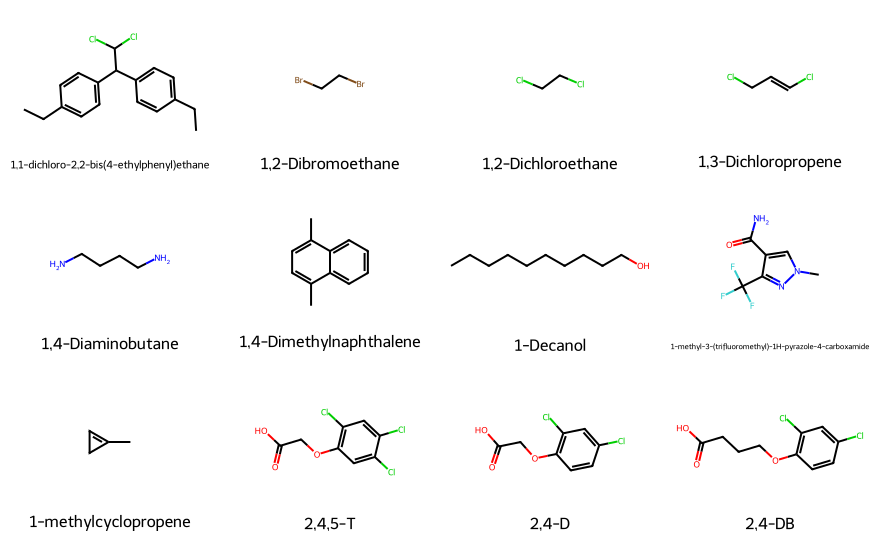

In [18]:
# Convert each SMILES string to an RDKit Mol object.
# Chem.MolFromSmiles returns None for invalid SMILES — we drop those.
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
df = df[df['mol'].notna()].reset_index(drop=True)

mols  = df['mol'].tolist()
names = df['name'].tolist()
print(f'Valid molecules: {len(mols)}')

# Quick visual check
Draw.MolsToGridImage(mols[:12], molsPerRow=4, subImgSize=(220, 180), legends=names[:12])

## 3 — Feature representation

We need to turn each molecule into a **vector of numbers** that a machine learning algorithm can work with.

Two main strategies:

| Strategy | Output type | Notes |
|---|---|---|
| **Fingerprints** (Options A–D) | Binary (0/1) | Fast, compact; binary values limit PCA quality |
| **Mordred descriptors** (Option E) | Continuous floats | 1826 physicochemical numbers; works well with PCA |

Uncomment exactly **one** block below.

In [19]:
# =============================================================
# CHOOSE YOUR FEATURE REPRESENTATION  (uncomment one block)
# =============================================================

# --- Option A: Morgan fingerprints (ECFP4-like) ---
# Circular, binary, 2048 bits. Standard in drug discovery.
# radius=2 means each atom's neighbourhood up to 2 bonds is encoded.
# Ref: https://greglandrum.github.io/rdkit-blog/posts/2023-01-18-fingerprint-generator-tutorial.html
# morgan_gen   = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
# fingerprints = np.array([morgan_gen.GetFingerprintAsNumPy(mol) for mol in mols])

# --- Option B: RDKit topological fingerprints ---
# Path-based, binary, 2048 bits. Captures linear bond paths through the molecule.
# Ref: https://www.rdkit.org/docs/GettingStartedInPython.html#fingerprinting-and-molecular-similarity
# rdkit_gen    = rdFingerprintGenerator.GetRDKitFPGenerator(maxPath=7, fpSize=2048)
# fingerprints = np.array([rdkit_gen.GetFingerprintAsNumPy(mol) for mol in mols])

# --- Option C: MACCS keys ---
# 166 predefined structural keys, binary. Simple and interpretable.
# from rdkit.Chem import rdMolDescriptors
# fingerprints = np.array([list(rdMolDescriptors.GetMACCSKeysFingerprint(mol)) for mol in mols])

# --- Option D: Atom-pair fingerprints ---
# Counts pairs of atom types at each graph distance, binary.
# apgen        = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=2048)
# fingerprints = np.array([apgen.GetFingerprintAsNumPy(mol) for mol in mols])

# --- Option E: Mordred descriptors (DEFAULT) ---
# 1826 continuous physicochemical descriptors per molecule.
# Continuous values give PCA more to work with than binary fingerprints.
# Ref: https://github.com/JacksonBurns/mordred-community
from mordred import Calculator, descriptors as mordred_descs
calc         = Calculator(mordred_descs, ignore_3D=True)
df_mord      = calc.pandas(mols)
df_mord      = df_mord.apply(pd.to_numeric, errors='coerce')           # error objects -> NaN
df_mord      = df_mord.dropna(axis=1, thresh=int(0.9 * len(df_mord))) # drop sparse columns
df_mord      = df_mord.fillna(df_mord.median())                        # fill remaining NaN
fingerprints = df_mord.values
print(f'Mordred: {fingerprints.shape[1]} descriptors for {fingerprints.shape[0]} molecules')

# Scale to zero mean, unit variance.
# Essential for continuous descriptors (Mordred) and recommended before all dim. reduction.
X = StandardScaler().fit_transform(fingerprints)
print(f'Scaled feature matrix X: {X.shape}')

100%|██████████| 495/495 [00:30<00:00, 16.14it/s]


Mordred: 1291 descriptors for 495 molecules
Scaled feature matrix X: (495, 1291)


## 4 — Physicochemical properties for colouring

We compute three simple, interpretable properties to **colour** every scatter plot.
This lets us see whether the dimensionality reduction is capturing chemical trends.

| Property | Symbol | Meaning |
|---|---|---|
| Molecular weight | MW | Size of the molecule (g/mol) |
| Lipophilicity | LogP | Affinity for oil vs water (higher = more fat-soluble) |
| Polar surface area | TPSA | Sum of polar atom surface areas; linked to membrane permeability |

Reference: [RDKit Descriptors](https://www.rdkit.org/docs/source/rdkit.Chem.Descriptors.html)

In [20]:
df['MolWt']   = [Descriptors.MolWt(mol)   for mol in mols]
df['MolLogP'] = [Descriptors.MolLogP(mol) for mol in mols]
df['TPSA']    = [Descriptors.TPSA(mol)    for mol in mols]

df[['name', 'MolWt', 'MolLogP', 'TPSA']].describe().round(1)

,MolWt,MolLogP,TPSA
count,495.0,495.0,495.0
mean,305.9,2.6,63.2
std,152.9,2.7,52.4
min,19.0,-14.3,0.0
25%,221.0,1.4,35.7
50%,301.3,3.0,53.1
75%,371.5,4.2,74.2
max,1732.2,16.8,535.6


In [21]:
# =============================================================
# CHOOSE COLORING VARIABLE  (uncomment exactly one line)
# =============================================================
# This variable is used to colour ALL scatter plots below.

# color_var, color_label = df['MolWt'],   'Mol. Weight (g/mol)'
color_var, color_label = np.log(df['MolWt']),   'ln( Mol. Weight (g/mol) )'
# color_var, color_label = df['MolLogP'], 'LogP (lipophilicity)'
# color_var, color_label  = df['TPSA'],    'TPSA (A^2)'   # <- active

## 5 — PCA: Principal Component Analysis

PCA finds the directions of **maximum variance** in the data and projects everything onto them.
It is **linear**, fast, and deterministic. The % variance explained tells you how much
information survives the compression to 2D.

Reference: [sklearn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

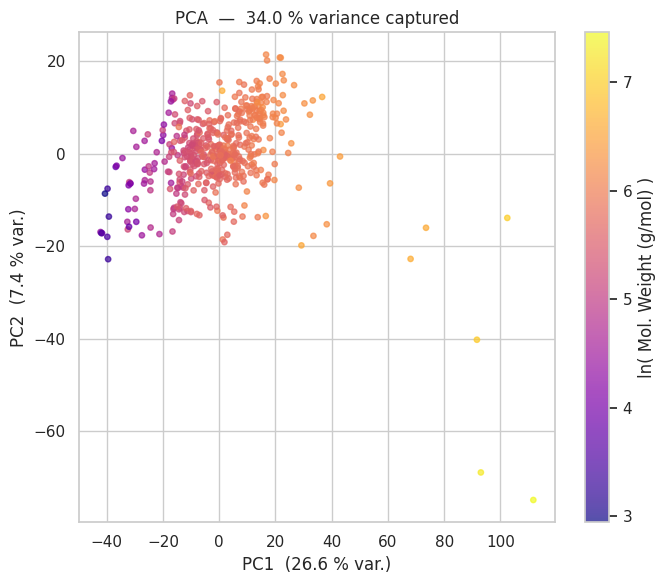

In [22]:
pca        = PCA(n_components=2, random_state=42)
coord_pca  = pca.fit_transform(X)
var        = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(coord_pca[:, 0], coord_pca[:, 1],
                c=color_var, cmap='plasma', alpha=0.7, s=15)
plt.colorbar(sc, ax=ax, label=color_label)
ax.set_xlabel(f'PC1  ({var[0]:.1f} % var.)')
ax.set_ylabel(f'PC2  ({var[1]:.1f} % var.)')
ax.set_title(f'PCA  —  {var[0] + var[1]:.1f} % variance captured')
plt.tight_layout()
plt.show()

## 6 — UMAP

UMAP (Uniform Manifold Approximation and Projection) is **non-linear** — it tries to keep
nearby molecules close in 2D while also preserving global structure.
Much faster than t-SNE and increasingly the standard method in cheminformatics.

- `n_neighbors` — how many neighbours define local structure (larger = more global view)
- `min_dist` — how tightly points are packed in the map

Reference: [umap-learn](https://umap-learn.readthedocs.io/en/latest/)

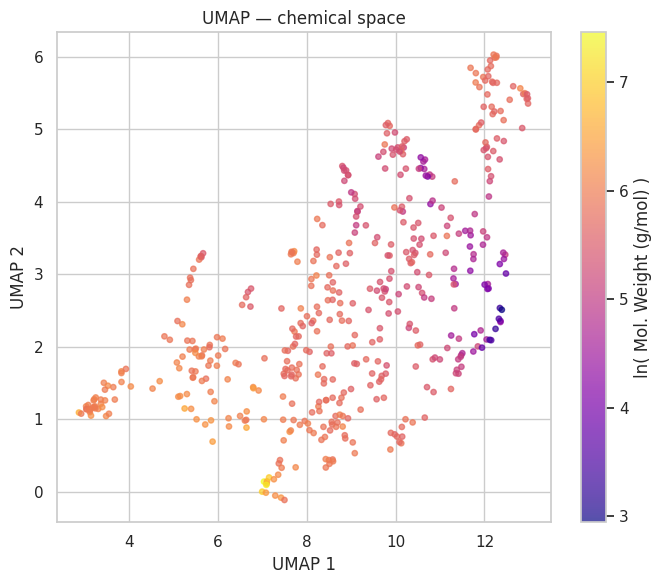

In [23]:
reducer    = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
coord_umap = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(coord_umap[:, 0], coord_umap[:, 1],
                c=color_var, cmap='plasma', alpha=0.7, s=15)
plt.colorbar(sc, ax=ax, label=color_label)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP — chemical space')
plt.tight_layout()
plt.show()

## 7 — t-SNE

t-SNE (t-distributed Stochastic Neighbour Embedding) is also **non-linear** and often reveals
tight local clusters very clearly. It is slower than UMAP and the axes carry no absolute meaning.

- `perplexity` ≈ effective number of neighbours. Try values between 5 and 50.
- Running PCA first (pre-reduce to ~50 components) speeds things up on large datasets.

Reference: [sklearn t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

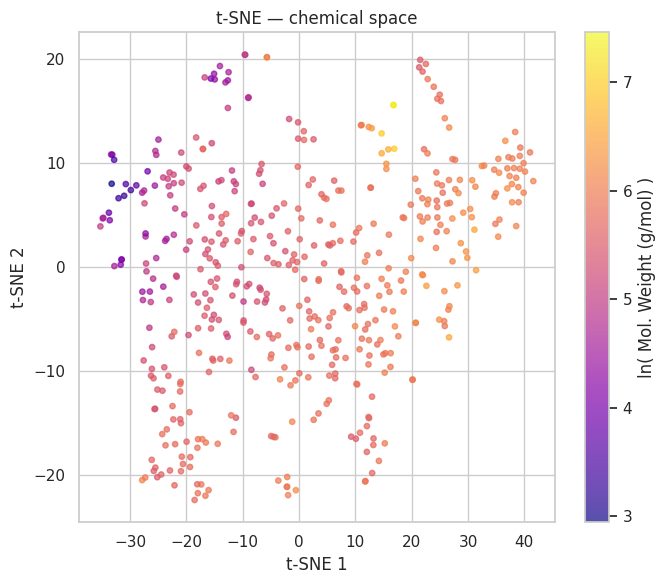

In [24]:
# Optional PCA pre-step: reduce to 50 components before running t-SNE.
# This is common practice and speeds up t-SNE significantly.
# Comment the next line out and replace X_pre with X below to skip it.
X_pre = PCA(n_components=50, random_state=42).fit_transform(X)

tsne       = TSNE(n_components=2, random_state=42)
# tsne       = TSNE(n_components=2, perplexity=30, random_state=42)
coord_tsne = tsne.fit_transform(X_pre)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(coord_tsne[:, 0], coord_tsne[:, 1],
                c=color_var, cmap='plasma', alpha=0.7, s=15)
plt.colorbar(sc, ax=ax, label=color_label)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE — chemical space')
plt.tight_layout()
plt.show()

## 8 — K-Means clustering

K-Means divides molecules into **k** groups by minimising within-cluster distances.
We will apply it in two ways:

1. **On the 2D t-SNE embedding** — clusters what you see in the plot
2. **On the full feature matrix X** — clusters in the original high-dimensional space (more rigorous)

First, use the **elbow plot** to choose a good value of k.

Reference: [sklearn KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

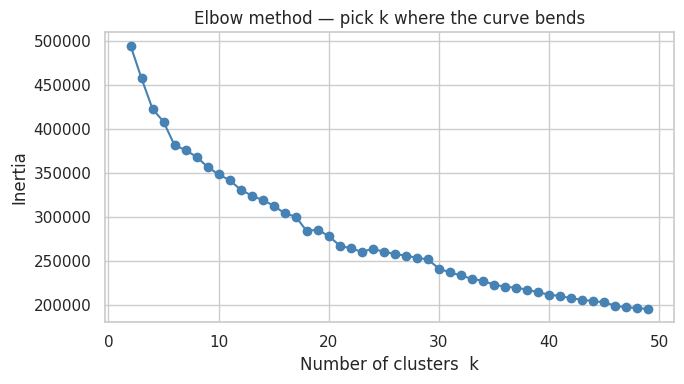

In [25]:
# Elbow method: fit K-Means for k = 2..11 and plot the inertia (within-cluster variance).
# The 'elbow' is the point where the curve stops dropping steeply.
inertias = []
k_range  = range(2, 50)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker='o', color='steelblue')
plt.xlabel('Number of clusters  k')
plt.ylabel('Inertia')
plt.title('Elbow method — pick k where the curve bends')
plt.tight_layout()
plt.show()

In [26]:
K = 6  # adjust based on the elbow plot above

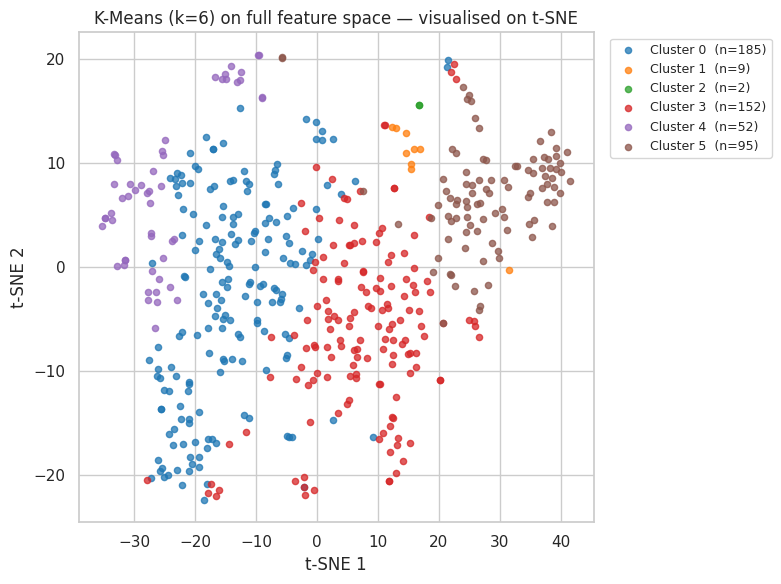

cluster
0    [1,4-Dimethylnaphthalene, 1-Decanol, 1-methyl-...
1    [24-Epibrassinolide, Azadirachtin, Fenbutatin ...
2                                [Abamectin, Spinosad]
3    [1,1-dichloro-2,2-bis(4-ethylphenyl)ethane, Ac...
4    [1,2-Dibromoethane, 1,2-Dichloroethane, 1,3-Di...
5    [Acrinathrin, Amidosulfuron, Amisulbrom, Azims...
Name: name, dtype: object

In [27]:
# --- K-Means on the full feature matrix X ---
# Clusters are formed in the original high-dimensional space.
# We then VISUALISE the result on the t-SNE plot (the axes stay the same).
km_full     = KMeans(n_clusters=K, random_state=42, n_init='auto')
labels_full = km_full.fit_predict(X)
df['cluster'] = labels_full

palette = sns.color_palette('tab10', K)
fig, ax = plt.subplots(figsize=(8, 6))
for cid in range(K):
    mask = labels_full == cid
    ax.scatter(coord_tsne[mask, 0], coord_tsne[mask, 1],
               label=f'Cluster {cid}  (n={mask.sum()})',
               color=palette[cid], alpha=0.75, s=20)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f'K-Means (k={K}) on full feature space — visualised on t-SNE')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Inspect which molecules landed in each cluster
df.groupby('cluster')['name'].apply(lambda x: list(x.head(4)))

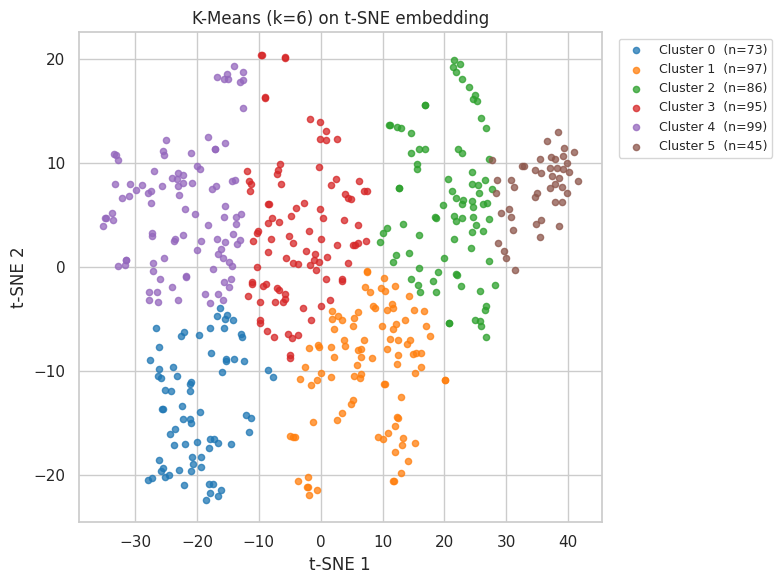

In [28]:
# --- K-Means on the 2D t-SNE coords ---
# Clusters the visual groups you see in the t-SNE plot.
# Compare with the previous plot: do the clusters look similar?
km_tsne     = KMeans(n_clusters=K, random_state=42, n_init='auto')
labels_tsne = km_tsne.fit_predict(coord_tsne)

palette = sns.color_palette('tab10', K)
fig, ax = plt.subplots(figsize=(8, 6))
for cid in range(K):
    mask = labels_tsne == cid
    ax.scatter(coord_tsne[mask, 0], coord_tsne[mask, 1],
               label=f'Cluster {cid}  (n={mask.sum()})',
               color=palette[cid], alpha=0.75, s=20)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f'K-Means (k={K}) on t-SNE embedding')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

Cluster 0  (73 molecules total)


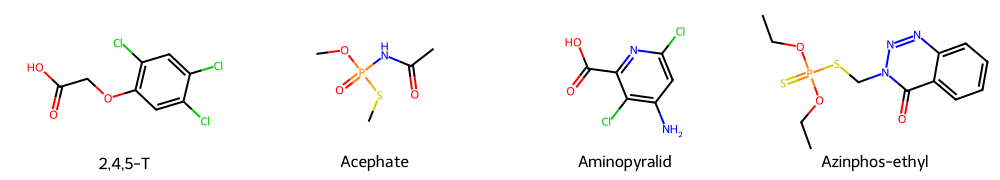

Cluster 1  (97 molecules total)


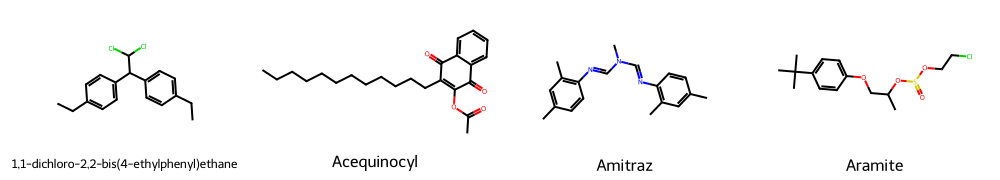

Cluster 2  (86 molecules total)


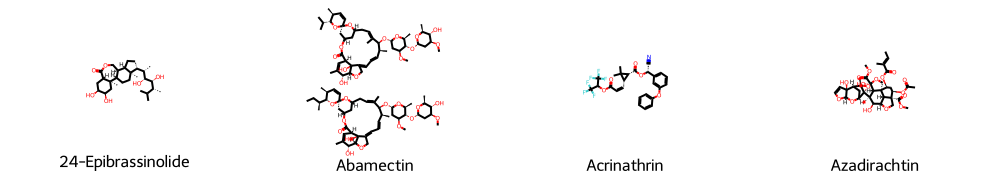

Cluster 3  (95 molecules total)


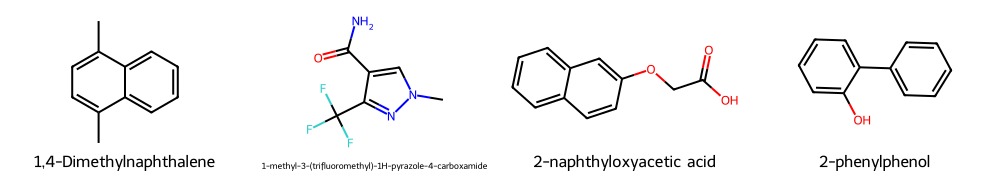

Cluster 4  (99 molecules total)


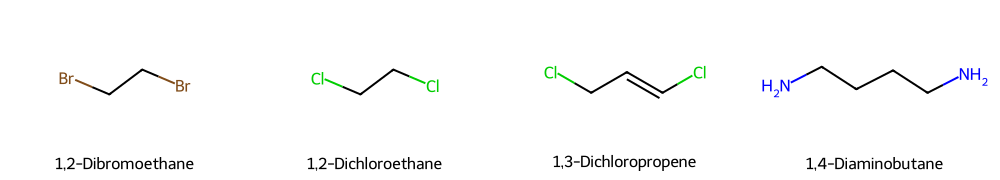

Cluster 5  (45 molecules total)


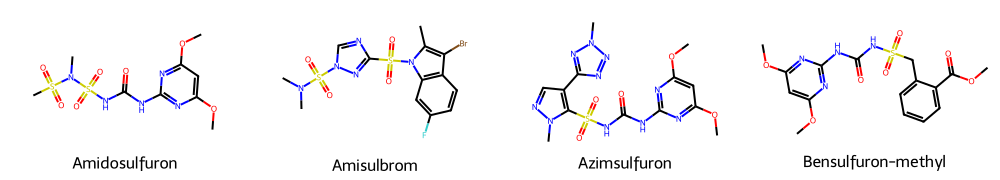

In [30]:
from IPython.display import display

for cid in range(K):
    # collect the first 4 molecules from this cluster
    idx           = [i for i, lbl in enumerate(labels_tsne) if lbl == cid][:4]
    cluster_mols  = [mols[i]  for i in idx]
    cluster_names = [names[i] for i in idx]

    print(f'Cluster {cid}  ({sum(labels_tsne == cid)} molecules total)')
    display(Draw.MolsToGridImage(
        cluster_mols,
        molsPerRow=4,
        subImgSize=(250, 180),
        legends=cluster_names
    ))


Cluster 0  (73 molecules total)
Cluster 1  (97 molecules total)
Cluster 2  (86 molecules total)
Cluster 3  (95 molecules total)
Cluster 4  (99 molecules total)
Cluster 5  (45 molecules total)


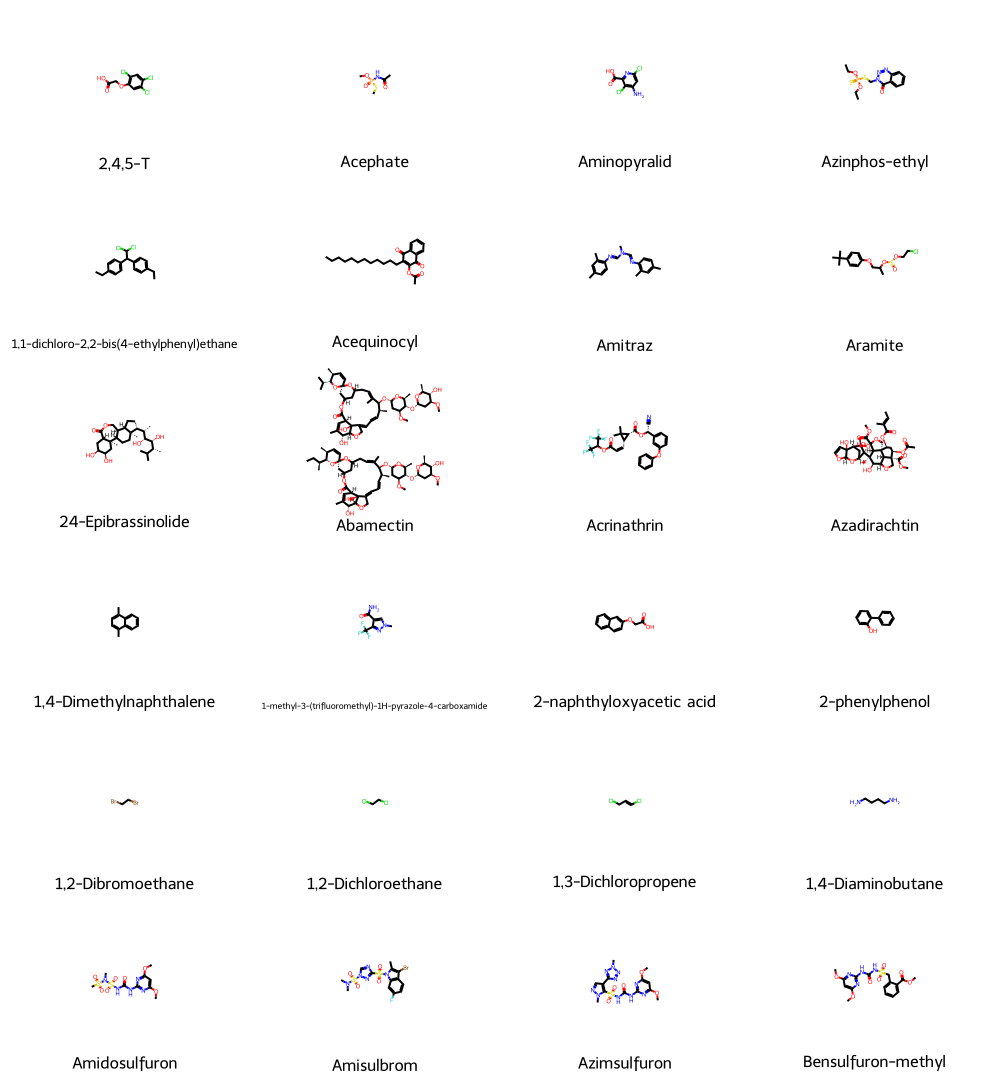

In [ ]:
cluster_mols = []
cluster_names = []

for cid in range(K):
    # collect the first 4 molecules from this cluster
    idx           = [i for i, lbl in enumerate(labels_tsne) if lbl == cid][:4]
    cluster_mols  += [mols[i]  for i in idx]
    cluster_names += [names[i] for i in idx]

    print(f'Cluster {cid}  ({sum(labels_tsne == cid)} molecules total)')

image = Draw.MolsToGridImage(
        cluster_mols,
        molsPerRow=4,
        subImgSize=(250, 180),
        legends=cluster_names
    )

### Further reading
- [RDKit Getting Started](https://www.rdkit.org/docs/GettingStartedInPython.html)
- [FingerprintGenerator tutorial](https://greglandrum.github.io/rdkit-blog/posts/2023-01-18-fingerprint-generator-tutorial.html)
- [Mordred community](https://github.com/JacksonBurns/mordred-community)
- [scikit-learn user guide](https://scikit-learn.org/stable/user_guide.html)
- [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/)
- [Practical Cheminformatics blog](http://practicalcheminformatics.blogspot.com/)